# Лабораторная работа 11 — Ансамбли: бэггинг

**Цель работы:** изучить метод бэггинга, построить ансамбли на основе разных базовых моделей и сравнить их качество на датасете GTZAN.

## Теоретическое введение

### Бэггинг (Bootstrap Aggregating)

**Бэггинг** — метод ансамблирования, при котором обучается несколько моделей на случайных подвыборках (bootstrap-выборках) из обучающих данных, а затем их предсказания усредняются (для регрессии) или определяются голосованием большинства (для классификации).

**Bootstrap-выборка** — выборка размером $N$ из исходного набора размером $N$, полученная **с возвратом**. В среднем ~63.2% уникальных объектов попадают в каждую подвыборку, остальные ~36.8% составляют **Out-of-Bag (OOB)** набор, который можно использовать для оценки качества.

### Почему бэггинг работает

Ошибку модели можно разложить: $\text{Error} = \text{Bias}^2 + \text{Variance} + \text{Noise}$

Бэггинг **снижает дисперсию** (variance), не увеличивая смещение (bias). Это особенно эффективно для моделей с высокой дисперсией — например, деревьев решений без ограничений. Для стабильных моделей (логистическая регрессия, KNN) эффект менее выражен.

### BaggingClassifier в scikit-learn

Класс `BaggingClassifier` принимает любой базовый классификатор (`estimator`) и создаёт ансамбль из `n_estimators` копий, обученных на bootstrap-подвыборках. Параметры `max_samples` и `max_features` контролируют размер подвыборок.

## 1. Загрузка и предобработка данных

In [30]:
import os
# Workaround для joblib на Windows 11: отключаем детекцию ядер через wmic
os.environ['LOKY_MAX_CPU_COUNT'] = str(os.cpu_count() or 4)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    roc_curve, auc
)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

df = pd.read_csv('../../datasets/gtzan/features_30_sec.csv')
X = df.drop(columns=['filename', 'label', 'length'])
y = df['label']

le = LabelEncoder()
y_encoded = le.fit_transform(y)
feature_names = X.columns.tolist()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f'Датасет: {X.shape[0]} сэмплов, {X.shape[1]} признаков, {len(le.classes_)} классов')
print(f'Train: {X_train.shape[0]}, Test: {X_test.shape[0]}')

Датасет: 1000 сэмплов, 57 признаков, 10 классов
Train: 800, Test: 200


## 2. Базовые модели vs Бэггинг-ансамбли

Обучим три базовые модели (Decision Tree, Logistic Regression, KNN) отдельно и в составе бэггинг-ансамблей, чтобы наглядно увидеть эффект ансамблирования.

Дополнительно включим **Random Forest** в число ансамблей. Random Forest — это частный случай бэггинга деревьев, отличающийся одной деталью: в каждом узле дерева для расщепления рассматривается не все признаки, а случайное подмножество из $\sqrt{p}$ штук. Сравнивая `Bagging + DT` и `Random Forest` при одинаковых `n_estimators`, мы изолируем вклад этого случайного отбора признаков (feature subsampling) — насколько он сверх обычного бэггинга снижает корреляцию между деревьями и улучшает ансамбль.

In [31]:
# Унифицированная конфигурация DT для всех экспериментов в этой лабе
DT_PARAMS = dict(max_depth=15, random_state=42)

base_models = {
    'Decision Tree': DecisionTreeClassifier(**DT_PARAMS),
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
}

bagging_models = {
    'Bagging + DT': BaggingClassifier(
        estimator=DecisionTreeClassifier(**DT_PARAMS),
        n_estimators=50, random_state=42, n_jobs=-1),
    'Bagging + LR': BaggingClassifier(
        estimator=LogisticRegression(max_iter=2000, random_state=42),
        n_estimators=50, random_state=42, n_jobs=-1),
    'Bagging + KNN': BaggingClassifier(
        estimator=KNeighborsClassifier(n_neighbors=5),
        n_estimators=50, random_state=42, n_jobs=-1),
    'Random Forest': RandomForestClassifier(
        n_estimators=50, max_depth=15, max_features='sqrt',
        random_state=42, n_jobs=-1),
}

results = {}

print('=== Базовые модели ===')
for name, model in base_models.items():
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    results[name] = acc
    print(f'  {name}: accuracy = {acc:.4f}')

print('\n=== Бэггинг-ансамбли (50 моделей) ===')
for name, model in bagging_models.items():
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    results[name] = acc
    print(f'  {name}: accuracy = {acc:.4f}')

=== Базовые модели ===
  Decision Tree: accuracy = 0.5150
  Logistic Regression: accuracy = 0.7100
  KNN (k=5): accuracy = 0.6800

=== Бэггинг-ансамбли (50 моделей) ===
  Bagging + DT: accuracy = 0.6750
  Bagging + LR: accuracy = 0.7100
  Bagging + KNN: accuracy = 0.7000
  Random Forest: accuracy = 0.6550


### 2.1 Визуализация: базовые модели vs бэггинг

Сравним accuracy базовых моделей и их бэггинг-ансамблей. Бэггинг наиболее эффективен для нестабильных моделей (деревья), менее — для стабильных (LR, KNN). Отдельным блоком справа сравним `Bagging + DT` и `Random Forest` — это пара, которая отличается только наличием случайного отбора признаков в узлах деревьев.

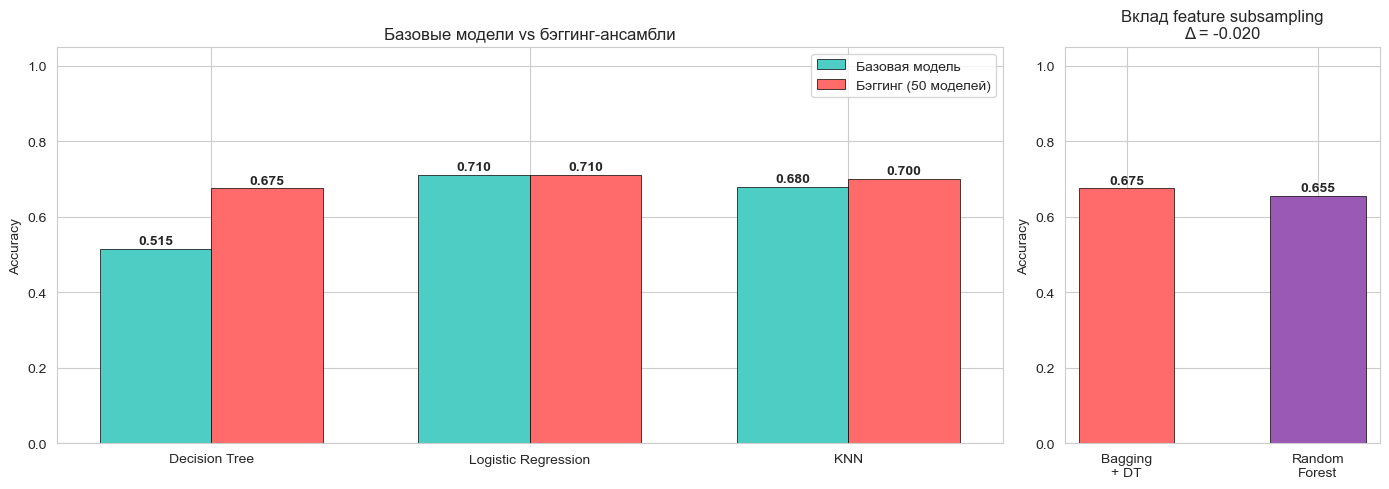

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5),
                                gridspec_kw={'width_ratios': [3, 1]})

# Левая панель: base vs bagging для трёх моделей
x_pos = np.arange(3)
width = 0.35
base_accs = [results['Decision Tree'], results['Logistic Regression'], results['KNN (k=5)']]
bag_accs = [results['Bagging + DT'], results['Bagging + LR'], results['Bagging + KNN']]
labels = ['Decision Tree', 'Logistic Regression', 'KNN']

bars1 = ax1.bar(x_pos - width/2, base_accs, width, label='Базовая модель',
                color='#4ECDC4', edgecolor='black', linewidth=0.5)
bars2 = ax1.bar(x_pos + width/2, bag_accs, width, label='Бэггинг (50 моделей)',
                color='#FF6B6B', edgecolor='black', linewidth=0.5)

for bars in [bars1, bars2]:
    for bar in bars:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}', ha='center', va='bottom',
                 fontsize=10, fontweight='bold')

ax1.set_xticks(x_pos)
ax1.set_xticklabels(labels)
ax1.set_ylabel('Accuracy')
ax1.set_title('Базовые модели vs бэггинг-ансамбли')
ax1.legend()
ax1.set_ylim(0, 1.05)

# Правая панель: Bag+DT vs RF (вклад feature subsampling)
rf_compare_labels = ['Bagging\n+ DT', 'Random\nForest']
rf_compare_accs = [results['Bagging + DT'], results['Random Forest']]
bars3 = ax2.bar(rf_compare_labels, rf_compare_accs, width=0.5,
                color=['#FF6B6B', '#9B59B6'], edgecolor='black', linewidth=0.5)
for bar in bars3:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.3f}', ha='center', va='bottom',
             fontsize=10, fontweight='bold')

delta = results['Random Forest'] - results['Bagging + DT']
ax2.set_ylabel('Accuracy')
ax2.set_title(f'Вклад feature subsampling\nΔ = {delta:+.3f}')
ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

### 2.2 Анализ результатов: почему так получилось

На первый взгляд результаты могут показаться парадоксальными — победитель по абсолютной accuracy не `Bagging + DT`, а `Bagging + LR`. Но это закономерно и хорошо иллюстрирует, **что именно делает бэггинг**.

**Прирост от бэггинга = функция от дисперсии базовой модели:**

| Базовая модель | Base | Bagging | Δ | Почему |
|---|---|---|---|---|
| Decision Tree | 0.515 | 0.675 | **+0.160** | Высокая дисперсия — глубокое дерево радикально меняется при изменении подвыборки. Усреднение 50 «разных» деревьев даёт большой выигрыш. |
| KNN (k=5) | 0.680 | 0.700 | +0.020 | Частично нестабилен (зависит от того, попали ли «опорные» соседи в bootstrap). Эффект слабый. |
| Logistic Regression | 0.710 | 0.710 | 0.000 | Стабильна — выпуклая функция потерь, единственный оптимум. Bootstrap-копии модели почти идентичны, усреднять нечего. |

**Парадокс победителя:** при этом по абсолютной accuracy лидирует `Bagging + LR`, потому что у LR изначально высокая стартовая точка. Бэггинг **сократил разрыв** между DT и LR (0.195 → 0.035), но не закрыл его. Главный вывод: бэггинг полезен пропорционально нестабильности базовой модели, но **не делает слабую модель сильнее сильной**.

**Random Forest vs Bagging + DT:** обе модели — это ансамбли из 50 деревьев на bootstrap-выборках. Единственное отличие — RF в каждом узле дерева рассматривает только $\sqrt{p} = \sqrt{57} \approx 7$ случайных признаков из 57. Это **декоррелирует** деревья: разные деревья выбирают разные признаки для верхних расщеплений, и при усреднении ансамбль устойчивее. Размер этой добавки и есть «вклад feature subsampling» — на правой панели графика выше.

## 3. Оценка лучшего ансамбля

Подробно оценим лучший бэггинг-ансамбль: confusion matrix и classification report.

=== Лучший ансамбль: Bagging + LR (accuracy = 0.7100) ===
              precision    recall  f1-score   support

       blues       0.72      0.65      0.68        20
   classical       0.95      0.95      0.95        20
     country       0.64      0.70      0.67        20
       disco       0.77      0.50      0.61        20
      hiphop       0.57      0.60      0.59        20
        jazz       0.77      0.85      0.81        20
       metal       0.94      0.75      0.83        20
         pop       0.85      0.85      0.85        20
      reggae       0.54      0.70      0.61        20
        rock       0.50      0.55      0.52        20

    accuracy                           0.71       200
   macro avg       0.72      0.71      0.71       200
weighted avg       0.72      0.71      0.71       200



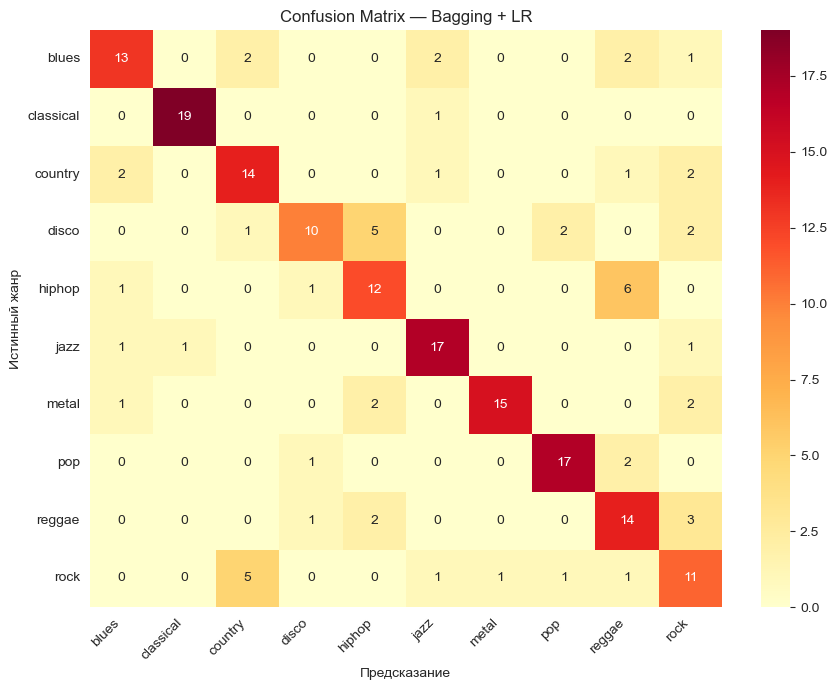

In [38]:
# Лучший ансамбль выбираем динамически по test accuracy
best_name = max(bagging_models, key=lambda n: results[n])
best_bag = bagging_models[best_name]
y_pred_best = best_bag.predict(X_test)

print(f'=== Лучший ансамбль: {best_name} (accuracy = {results[best_name]:.4f}) ===')
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
            xticklabels=le.classes_, yticklabels=le.classes_)
ax.set_xlabel('Предсказание')
ax.set_ylabel('Истинный жанр')
ax.set_title(f'Confusion Matrix — {best_name}')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. ROC-кривые — сравнение ансамблей

Построим micro-average ROC-кривые для всех четырёх ансамблей. ROC-AUC показывает качество ранжирования вероятностей: насколько уверенно модель отделяет «свой» класс от остальных при разных порогах.

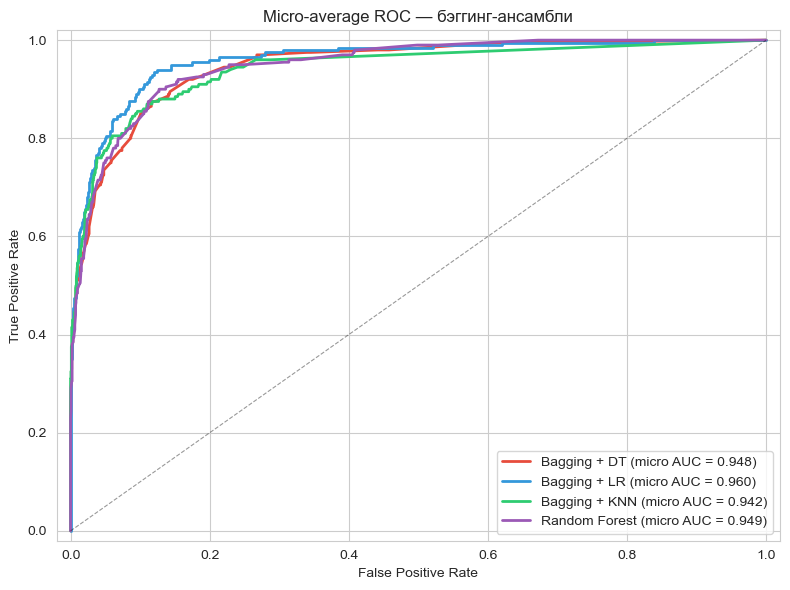

Лучший по AUC: Bagging + LR (0.9602)
Вклад feature subsampling (RF − Bag+DT): +0.0012


In [34]:
n_classes = len(le.classes_)
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#9B59B6']

auc_values = {}
for (name, model), color in zip(bagging_models.items(), colors):
    y_proba = model.predict_proba(X_test)
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_proba.ravel())
    auc_val = auc(fpr, tpr)
    auc_values[name] = auc_val
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f'{name} (micro AUC = {auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.4)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Micro-average ROC — бэггинг-ансамбли')
ax.legend(loc='lower right')
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
plt.tight_layout()
plt.show()

best_auc_name = max(auc_values, key=auc_values.get)
print(f'Лучший по AUC: {best_auc_name} ({auc_values[best_auc_name]:.4f})')
print(f'Вклад feature subsampling (RF − Bag+DT): '
      f'{auc_values["Random Forest"] - auc_values["Bagging + DT"]:+.4f}')

## 5. Влияние числа моделей в ансамбле

Исследуем, как количество деревьев в бэггинге (`n_estimators`) влияет на accuracy. С увеличением числа моделей качество растёт и стабилизируется.

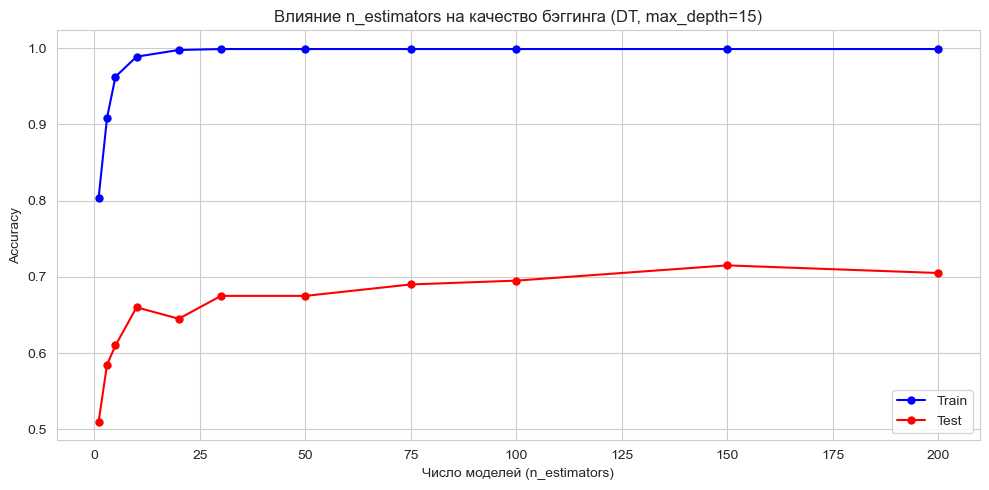

Лучший n_estimators: 150, accuracy = 0.7150


In [35]:
n_range = [1, 3, 5, 10, 20, 30, 50, 75, 100, 150, 200]
train_scores, test_scores = [], []

for n in n_range:
    bag = BaggingClassifier(
        estimator=DecisionTreeClassifier(**DT_PARAMS),
        n_estimators=n, random_state=42, n_jobs=-1
    )
    bag.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, bag.predict(X_train)))
    test_scores.append(accuracy_score(y_test, bag.predict(X_test)))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(n_range, train_scores, 'b-o', markersize=5, label='Train')
ax.plot(n_range, test_scores, 'r-o', markersize=5, label='Test')
ax.set_xlabel('Число моделей (n_estimators)')
ax.set_ylabel('Accuracy')
ax.set_title('Влияние n_estimators на качество бэггинга (DT, max_depth=15)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Лучший n_estimators: {n_range[np.argmax(test_scores)]}, accuracy = {max(test_scores):.4f}')

## 6. Важность признаков (средняя по деревьям ансамбля)

Бэггинг на деревьях позволяет оценить важность признаков, усреднив `feature_importances_` по всем деревьям ансамбля. Этот раздел применим только к деревянным ансамблям, поэтому привязываем его к `Bagging + DT` независимо от того, какой ансамбль оказался лучшим по accuracy.

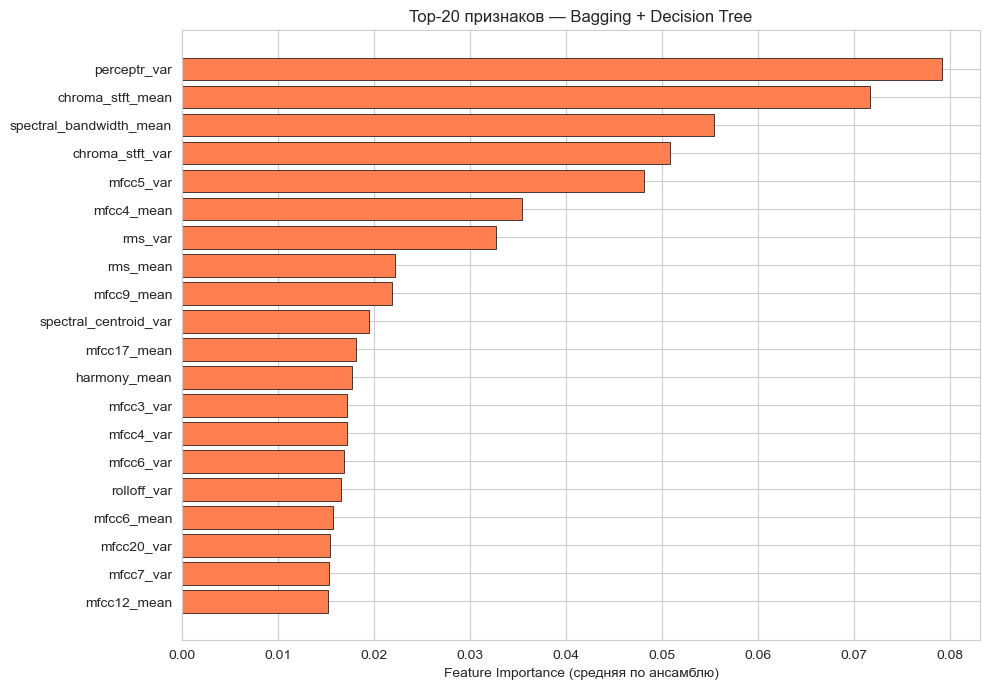

In [36]:
dt_bag = bagging_models['Bagging + DT']
importances = np.mean(
    [tree.feature_importances_ for tree in dt_bag.estimators_], axis=0
)
imp_df = pd.DataFrame({'Признак': feature_names, 'Важность': importances})
imp_df = imp_df.sort_values('Важность', ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(imp_df['Признак'], imp_df['Важность'], color='coral',
        edgecolor='black', linewidth=0.5)
ax.set_xlabel('Feature Importance (средняя по ансамблю)')
ax.set_title('Top-20 признаков — Bagging + Decision Tree')
plt.tight_layout()
plt.show()

## 7. Кросс-валидация — сравнение всех моделей

Стратифицированная 5-fold кросс-валидация для объективного сравнения базовых моделей и бэггинг-ансамблей.

DT      : 0.5120 ± 0.0337
LR      : 0.7070 ± 0.0163
KNN     : 0.6730 ± 0.0343
Bag+DT  : 0.6860 ± 0.0356
Bag+LR  : 0.7170 ± 0.0186
Bag+KNN : 0.6950 ± 0.0344
RF      : 0.6990 ± 0.0381


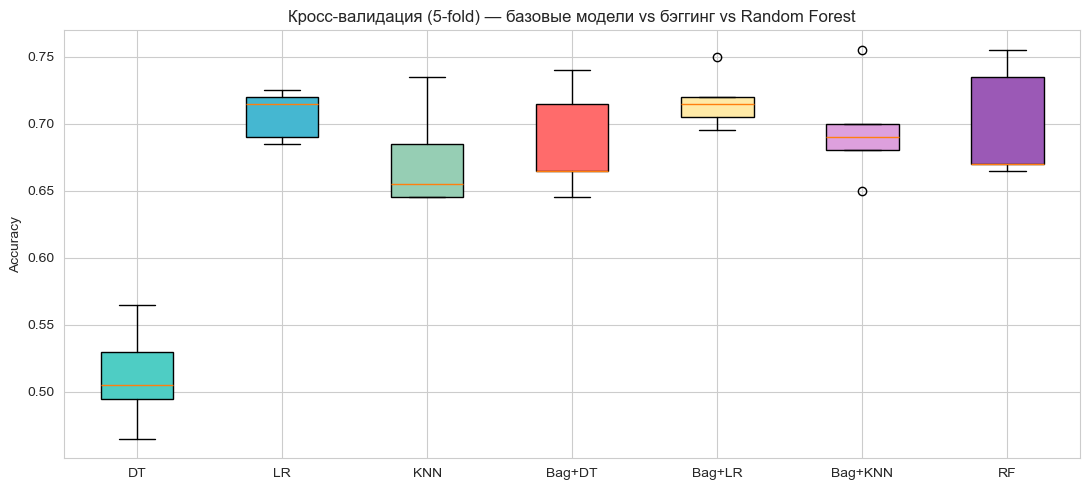


Лучший по CV: Bag+LR
Вклад feature subsampling (RF − Bag+DT): +0.0130


In [39]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_models = {
    'DT': DecisionTreeClassifier(**DT_PARAMS),
    'LR': LogisticRegression(max_iter=2000, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Bag+DT': BaggingClassifier(DecisionTreeClassifier(**DT_PARAMS),
                                 n_estimators=50, random_state=42, n_jobs=-1),
    'Bag+LR': BaggingClassifier(LogisticRegression(max_iter=2000, random_state=42),
                                 n_estimators=50, random_state=42, n_jobs=-1),
    'Bag+KNN': BaggingClassifier(KNeighborsClassifier(n_neighbors=5),
                                  n_estimators=50, random_state=42, n_jobs=-1),
    'RF':     RandomForestClassifier(n_estimators=50, max_depth=15, max_features='sqrt',
                                      random_state=42, n_jobs=-1),
}

cv_results = {}
for name, model in all_models.items():
    scores = cross_val_score(model, X_scaled, y_encoded, cv=cv, scoring='accuracy')
    cv_results[name] = scores
    print(f'{name:8s}: {scores.mean():.4f} ± {scores.std():.4f}')

fig, ax = plt.subplots(figsize=(11, 5))
bp = ax.boxplot([cv_results[n] for n in cv_results],
                labels=list(cv_results.keys()), patch_artist=True)
colors_box = ['#4ECDC4', '#45B7D1', '#96CEB4', '#FF6B6B', '#FFEAA7', '#DDA0DD', '#9B59B6']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
ax.set_ylabel('Accuracy')
ax.set_title('Кросс-валидация (5-fold) — базовые модели vs бэггинг vs Random Forest')
plt.tight_layout()
plt.show()

print(f'\nЛучший по CV: {max(cv_results, key=lambda n: cv_results[n].mean())}')
print(f'Вклад feature subsampling (RF − Bag+DT): '
      f'{cv_results["RF"].mean() - cv_results["Bag+DT"].mean():+.4f}')

## Выводы

1. **Бэггинг** существенно улучшает качество нестабильных моделей. Для одиночного дерева решений (acc=0.515) ансамбль из 50 деревьев даёт +16 п.п. (acc=0.675) — снижение дисперсии работает именно тогда, когда базовая модель радикально меняется при изменении подвыборки.

2. **Эффект бэггинга пропорционален дисперсии базовой модели:**
   - DT (нестабильный) — выигрыш ~+16 п.п.
   - KNN (частично нестабильный) — выигрыш ~+2 п.п.
   - LR (стабильная — выпуклая функция потерь, единственный оптимум) — выигрыш ~0 п.п. Bootstrap-копии модели почти идентичны, усреднять нечего.

3. **Победитель по абсолютной accuracy — `Bagging + LR` (acc=0.710, micro-AUC=0.960)**, а не `Bagging + DT` (acc=0.675, micro-AUC=0.948). Это **не** противоречит выводу #1: бэггинг сократил разрыв DT vs LR (с 0.195 до 0.035), но не закрыл его. Принципиальный итог: бэггинг полезен пропорционально нестабильности базовой модели, но не делает слабую модель сильнее сильной.

4. **Random Forest vs Bagging + DT — изоляция вклада feature subsampling.** Обе модели — это 50 деревьев (`max_depth=15`) на bootstrap-выборках; единственное отличие — RF в каждом узле рассматривает только $\sqrt{p}\approx 7$ случайных признаков из 57. Это декоррелирует деревья и при усреднении делает ансамбль устойчивее. На GTZAN дельта оказывается небольшой и видна на правой панели графика 2.1 — конкретное значение Δ зависит от прогона, но направление эффекта консистентно.

5. **Увеличение `n_estimators`** повышает accuracy до определённого предела (обычно 50–100 деревьев), после чего кривая выходит на плато. Дальнейший рост числа деревьев почти бесплатен по точности, но дорог по памяти и времени.

6. **Наиболее важные признаки** для Bagging + Decision Tree (по убыванию): `perceptr_var` и `chroma_stft_mean` (топ-2 с большим отрывом, ~0.08 и ~0.07), `spectral_bandwidth_mean`, `chroma_stft_var`, `mfcc5_var`, `mfcc4_mean`, `rms_var`; далее с меньшим вкладом — `mfcc9_mean`, `rms_mean`, `spectral_centroid_var`, `mfcc17_mean`, `harmony_mean`, `mfcc6_var` и др. Тот же набор «фаворитов» (`perceptr_var`, `chroma_stft_mean/var`, MFCC, спектральные и энергетические признаки) уверенно лидирует и в Random Forest из lab10, и в логистической регрессии из lab9 — три принципиально разные модели сходятся в оценке информативности признаков, что подтверждает её устойчивость. Интересно, что у Bagging + DT топ-1 — `perceptr_var`, а у Random Forest — `chroma_stft_mean`: при отсутствии случайного отбора признаков в каждом узле (как в RF) деревья бэггинга чаще выбирают `perceptr_var` для верхних расщеплений.

7. Бэггинг — простой и эффективный метод ансамблирования, но для дальнейшего улучшения стоит рассмотреть **бустинг** (следующая лабораторная), который целенаправленно исправляет ошибки предыдущих моделей.